In [320]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from collections import Counter
import numpy as np
from category_encoders import TargetEncoder
import re 
import ast 
from datetime import datetime 
from sklearn.feature_extraction.text import TfidfVectorizer

In [321]:
df=pd.read_csv("data/listings.csv") 

In [322]:
df.head() 

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,27886,https://www.airbnb.com/rooms/27886,20250911031321,2025-09-11,city scrape,"Romantic, stylish B&B houseboat in canal district",Stylish and romantic houseboat on fantastic hi...,"Central, quiet, safe, clean and beautiful.",https://a0.muscache.com/pictures/02c2da9d-660e...,97647,...,4.93,4.90,4.78,0363 974D 4986 7411 88D8,f,1,0,1,0,1.87
1,28871,https://www.airbnb.com/rooms/28871,20250911031321,2025-09-11,city scrape,Comfortable double room,Basic bedroom in the center of Amsterdam.,"Flower market , Leidseplein , Rembrantsplein",https://a0.muscache.com/pictures/160889/362340...,124245,...,4.94,4.93,4.83,0363 607B EA74 0BD8 2F6F,f,2,0,2,0,3.99
2,29051,https://www.airbnb.com/rooms/29051,20250911031321,2025-09-11,city scrape,Comfortable single / double room,This room can also be rented as a single or a ...,the street is quite lively especially on weeke...,https://a0.muscache.com/pictures/162009/bd6be2...,124245,...,4.92,4.87,4.79,0363 607B EA74 0BD8 2F6F,f,2,0,2,0,4.81
3,44391,https://www.airbnb.com/rooms/44391,20250911031321,2025-09-11,previous scrape,Quiet 2-bedroom Amsterdam city centre apartment,Guests greatly appreciate the unique location ...,The appartment is located in the city centre. ...,https://a0.muscache.com/pictures/97741545/3900...,194779,...,4.90,4.68,4.50,0363 E76E F06A C1DD 172C,f,1,1,0,0,0.23
4,48373,https://www.airbnb.com/rooms/48373,20250911031321,2025-09-11,previous scrape,Cozy family home in Amsterdam South,Charming modern apartment in the quiet and gre...,Apartment is located between Amsterdamse Bos a...,https://a0.muscache.com/pictures/miso/Hosting-...,220434,...,5.00,4.60,5.00,0363 4A2B A6AD 0196 F684,f,1,1,0,0,0.19


In [323]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 10480 entries, 0 to 10479
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            10480 non-null  int64  
 1   listing_url                                   10480 non-null  str    
 2   scrape_id                                     10480 non-null  int64  
 3   last_scraped                                  10480 non-null  str    
 4   source                                        10480 non-null  str    
 5   name                                          10480 non-null  str    
 6   description                                   10132 non-null  str    
 7   neighborhood_overview                         5192 non-null   str    
 8   picture_url                                   10480 non-null  str    
 9   host_id                                       10480 non-null  int64  
 1

There are 4606 number of company that do not have any price value provided, so when can simple drop those column

In [324]:
# create list of row indices where the price is null/blank
row_indices=df.index[(df["price"].isnull())].tolist() 
len(row_indices)

4606

In [325]:
df.drop(index=row_indices,inplace=True) 

In [326]:
len(df)

5874

In [327]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,27886,https://www.airbnb.com/rooms/27886,20250911031321,2025-09-11,city scrape,"Romantic, stylish B&B houseboat in canal district",Stylish and romantic houseboat on fantastic hi...,"Central, quiet, safe, clean and beautiful.",https://a0.muscache.com/pictures/02c2da9d-660e...,97647,...,4.93,4.90,4.78,0363 974D 4986 7411 88D8,f,1,0,1,0,1.87
1,28871,https://www.airbnb.com/rooms/28871,20250911031321,2025-09-11,city scrape,Comfortable double room,Basic bedroom in the center of Amsterdam.,"Flower market , Leidseplein , Rembrantsplein",https://a0.muscache.com/pictures/160889/362340...,124245,...,4.94,4.93,4.83,0363 607B EA74 0BD8 2F6F,f,2,0,2,0,3.99
2,29051,https://www.airbnb.com/rooms/29051,20250911031321,2025-09-11,city scrape,Comfortable single / double room,This room can also be rented as a single or a ...,the street is quite lively especially on weeke...,https://a0.muscache.com/pictures/162009/bd6be2...,124245,...,4.92,4.87,4.79,0363 607B EA74 0BD8 2F6F,f,2,0,2,0,4.81
5,49552,https://www.airbnb.com/rooms/49552,20250911031321,2025-09-11,city scrape,Multatuli Luxury Guest Suite in top location,Stylish & spacious 60m2 guest suite in Amsterd...,You will find yourself in a quiet side street ...,https://a0.muscache.com/pictures/a6d6d2ee-3196...,225987,...,4.97,4.98,4.78,0363 576A D827 5085 6B83,f,1,1,0,0,3.36
6,50263,https://www.airbnb.com/rooms/50263,20250911031321,2025-09-11,city scrape,Central de Lux 2 bedrooms (4p) apt 125 sqm,A beautiful 'De Lux' 125 sqm apartment for 4 a...,The house is located in a green park where no...,https://a0.muscache.com/pictures/677876/7cb949...,230246,...,4.76,4.66,4.75,0363 7F3D 0BAE 28C8 C7D2,f,1,1,0,0,0.97


In [328]:
df.info() 

<class 'pandas.DataFrame'>
Index: 5874 entries, 0 to 10479
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            5874 non-null   int64  
 1   listing_url                                   5874 non-null   str    
 2   scrape_id                                     5874 non-null   int64  
 3   last_scraped                                  5874 non-null   str    
 4   source                                        5874 non-null   str    
 5   name                                          5874 non-null   str    
 6   description                                   5657 non-null   str    
 7   neighborhood_overview                         2755 non-null   str    
 8   picture_url                                   5874 non-null   str    
 9   host_id                                       5874 non-null   int64  
 10  hos

In [329]:
df.tail(10) 

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
10470,1502865938487978016,https://www.airbnb.com/rooms/1502865938487978016,20250911031321,2025-09-11,city scrape,Cosy one bedroom apartment in Amsterdam Noord,"Kick back and relax in this calm, stylish spac...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,102449031,...,NaN,NaN,NaN,0363 2AB1 E13E D42F 386D,f,1,1,0,0,NaN
10471,1503145545400026458,https://www.airbnb.com/rooms/1503145545400026458,20250911031321,2025-09-11,city scrape,Downtown apartment w/terrasse and view to a canal,NaN,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,22534485,...,NaN,NaN,NaN,NaN,f,1,0,1,0,NaN
10472,1503399985423712696,https://www.airbnb.com/rooms/1503399985423712696,20250911031321,2025-09-11,city scrape,The Staal House,"Welcome to The Staal House, your cozy Amsterda...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,420845707,...,NaN,NaN,NaN,0363 7302 7B95 4CF8 8169,t,1,1,0,0,NaN
10473,1503475250056511603,https://www.airbnb.com/rooms/1503475250056511603,20250911031321,2025-09-11,city scrape,Comfortable spacious apartment in great location,Comfortable and spacious apartment located clo...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,175885486,...,NaN,NaN,NaN,0363 AA29 4900 1AD4 76A9,f,1,1,0,0,NaN
10474,1503528945274992542,https://www.airbnb.com/rooms/1503528945274992542,20250911031321,2025-09-11,city scrape,Pearl of the Cuyp | Modern Comfort in De Pijp,- Renovated 2-bedroom apartment in lively De P...,"You’ll be staying in De Pijp, one of Amsterdam...",https://a0.muscache.com/pictures/hosting/Hosti...,717346955,...,NaN,NaN,NaN,0363 033B 7FC4 5C3A DB9F,t,1,1,0,0,NaN
10475,1503867342263201504,https://www.airbnb.com/rooms/1503867342263201504,20250911031321,2025-09-11,city scrape,"test host, don't book",NaN,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,78127165,...,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN
10476,1504985777531398085,https://www.airbnb.com/rooms/1504985777531398085,20250911031321,2025-09-11,city scrape,Bright studio with canal view,This is bright and stylish fully furnished stu...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,613779,...,NaN,NaN,NaN,0363F7E548AEB29F3BA3,f,4,4,0,0,NaN
10477,1504998100462399057,https://www.airbnb.com/rooms/1504998100462399057,20250911031321,2025-09-11,city scrape,Bright & Spacious Luxury Corner Apartment,Experience Amsterdam in style at our 100 m² pr...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,715849738,...,NaN,NaN,NaN,0363 5876 BBB2 EF1F 097D,f,1,1,0,0,NaN
10478,1505255613607359391,https://www.airbnb.com/rooms/1505255613607359391,20250911031321,2025-09-11,city scrape,Bright and Spacious Ground Floor App. with Garden,Enjoy a bright and modern one-bedroom apartmen...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,31681093,...,NaN,NaN,NaN,0363 3146 D0B7 73A7 E9FA,f,1,1,0,0,NaN
10479,1506287353709120640,https://www.airbnb.com/rooms/1506287353709120640,20250911031321,2025-09-11,city scrape,Stylish & cozy apartment in Amsterdam West,Welcome to our sun-drenched apartment on the 3...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,32442604,...,NaN,NaN,NaN,0363 044C 2949 EABC E0B8,f,1,1,0,0,NaN


In [330]:
# X=df.drop(columns=["price"])
# y=df.price 

In [331]:
# X_train, X_test, y_train, y_test = train_test_split(X , y, test_size=0.2, random_state=42)

In [332]:
# X_test['price']=y_test
# X_train['price']=y_train 

# train_data=X_train
# test_data=X_test

# print(f"train_data datapoints: {len(train_data)}")
# print(f"test_data datapoints: {len(test_data)}")


In [333]:
# train_data[:10] 

In [334]:
col_nunique={} 
for i in df.columns: 
    col_nunique.update({f"{i}": df[f"{i}"].nunique()})
col_nunique  

{'id': 5874,
 'listing_url': 5874,
 'scrape_id': 1,
 'last_scraped': 1,
 'source': 1,
 'name': 5751,
 'description': 5470,
 'neighborhood_overview': 2489,
 'picture_url': 5818,
 'host_id': 5045,
 'host_url': 5045,
 'host_name': 2543,
 'host_since': 2805,
 'host_location': 124,
 'host_about': 2504,
 'host_response_time': 4,
 'host_response_rate': 64,
 'host_acceptance_rate': 101,
 'host_is_superhost': 2,
 'host_thumbnail_url': 4960,
 'host_picture_url': 4960,
 'host_neighbourhood': 64,
 'host_listings_count': 35,
 'host_total_listings_count': 46,
 'host_verifications': 7,
 'host_has_profile_pic': 2,
 'host_identity_verified': 2,
 'neighbourhood': 32,
 'neighbourhood_cleansed': 22,
 'neighbourhood_group_cleansed': 0,
 'latitude': 4858,
 'longitude': 5212,
 'property_type': 57,
 'room_type': 4,
 'accommodates': 13,
 'bathrooms': 15,
 'bathrooms_text': 23,
 'bedrooms': 11,
 'beds': 22,
 'amenities': 5696,
 'price': 663,
 'minimum_nights': 42,
 'maximum_nights': 104,
 'minimum_minimum_night

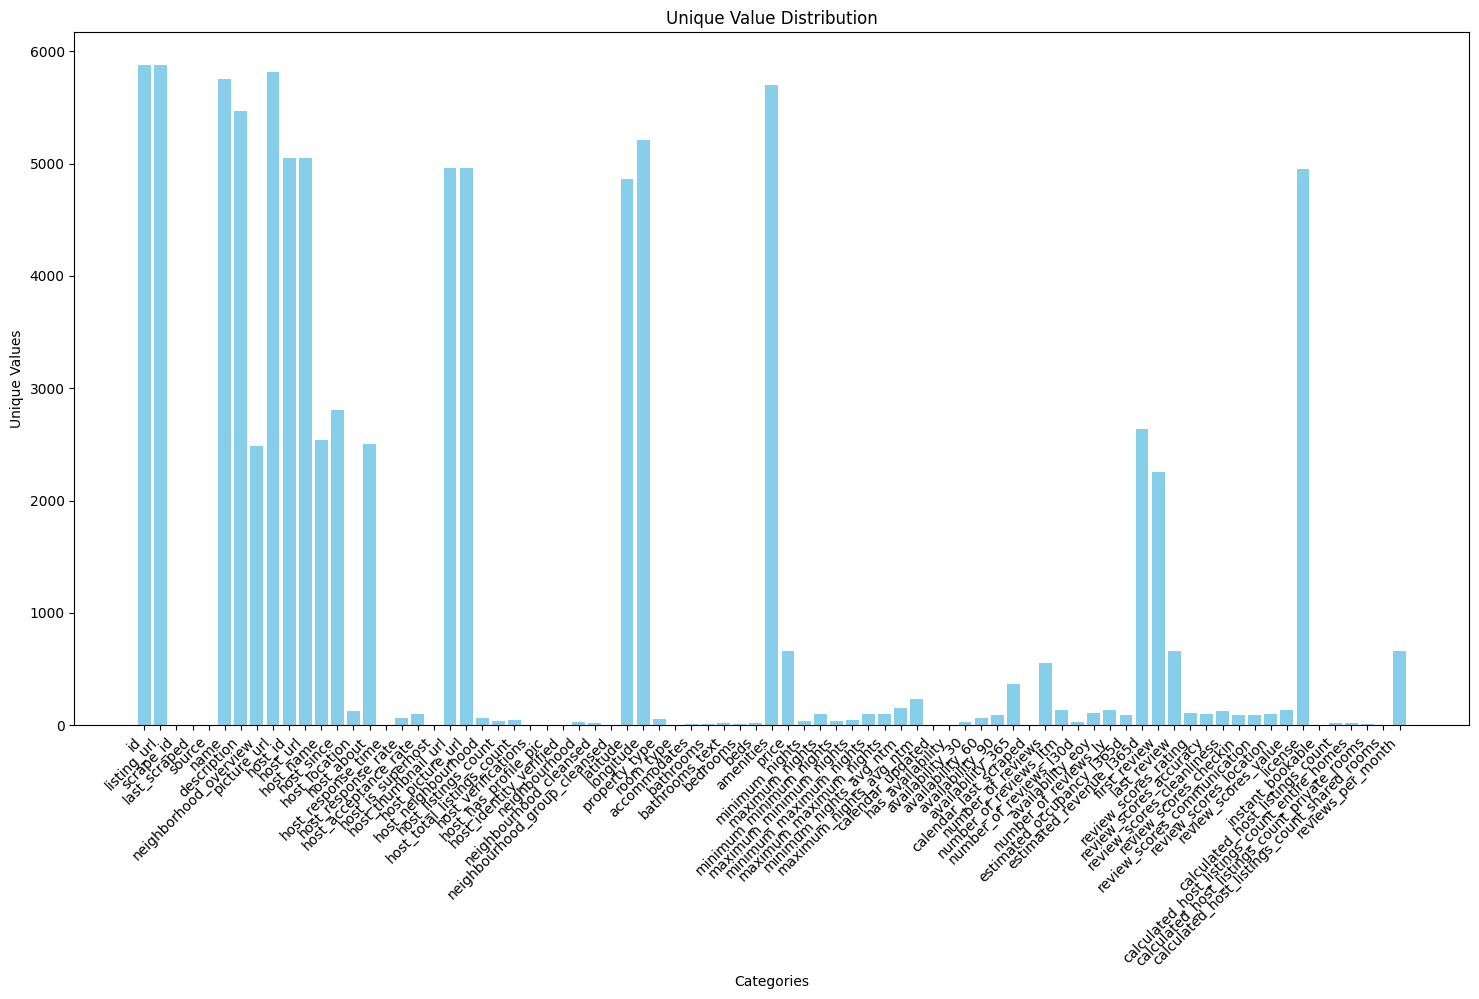

In [335]:
categories=col_nunique.keys()
no_unique_values=col_nunique.values()

plt.figure(figsize=(18,9))
plt.bar(categories, no_unique_values, color="skyblue")
plt.xlabel("Categories")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Unique Values")
plt.title("Unique Value Distribution")

plt.show()

In [336]:
categories_null_count={}
for i in df.columns: 
    categories_null_count.update({i:int(df[f"{i}"].isnull().sum())})
categories_null_count 

{'id': 0,
 'listing_url': 0,
 'scrape_id': 0,
 'last_scraped': 0,
 'source': 0,
 'name': 0,
 'description': 217,
 'neighborhood_overview': 3119,
 'picture_url': 0,
 'host_id': 0,
 'host_url': 0,
 'host_name': 2,
 'host_since': 2,
 'host_location': 689,
 'host_about': 2752,
 'host_response_time': 851,
 'host_response_rate': 851,
 'host_acceptance_rate': 393,
 'host_is_superhost': 59,
 'host_thumbnail_url': 2,
 'host_picture_url': 2,
 'host_neighbourhood': 4431,
 'host_listings_count': 2,
 'host_total_listings_count': 2,
 'host_verifications': 2,
 'host_has_profile_pic': 2,
 'host_identity_verified': 2,
 'neighbourhood': 3119,
 'neighbourhood_cleansed': 0,
 'neighbourhood_group_cleansed': 5874,
 'latitude': 0,
 'longitude': 0,
 'property_type': 0,
 'room_type': 0,
 'accommodates': 0,
 'bathrooms': 0,
 'bathrooms_text': 6,
 'bedrooms': 9,
 'beds': 3,
 'amenities': 0,
 'price': 0,
 'minimum_nights': 0,
 'maximum_nights': 0,
 'minimum_minimum_nights': 4,
 'maximum_minimum_nights': 4,
 'mini

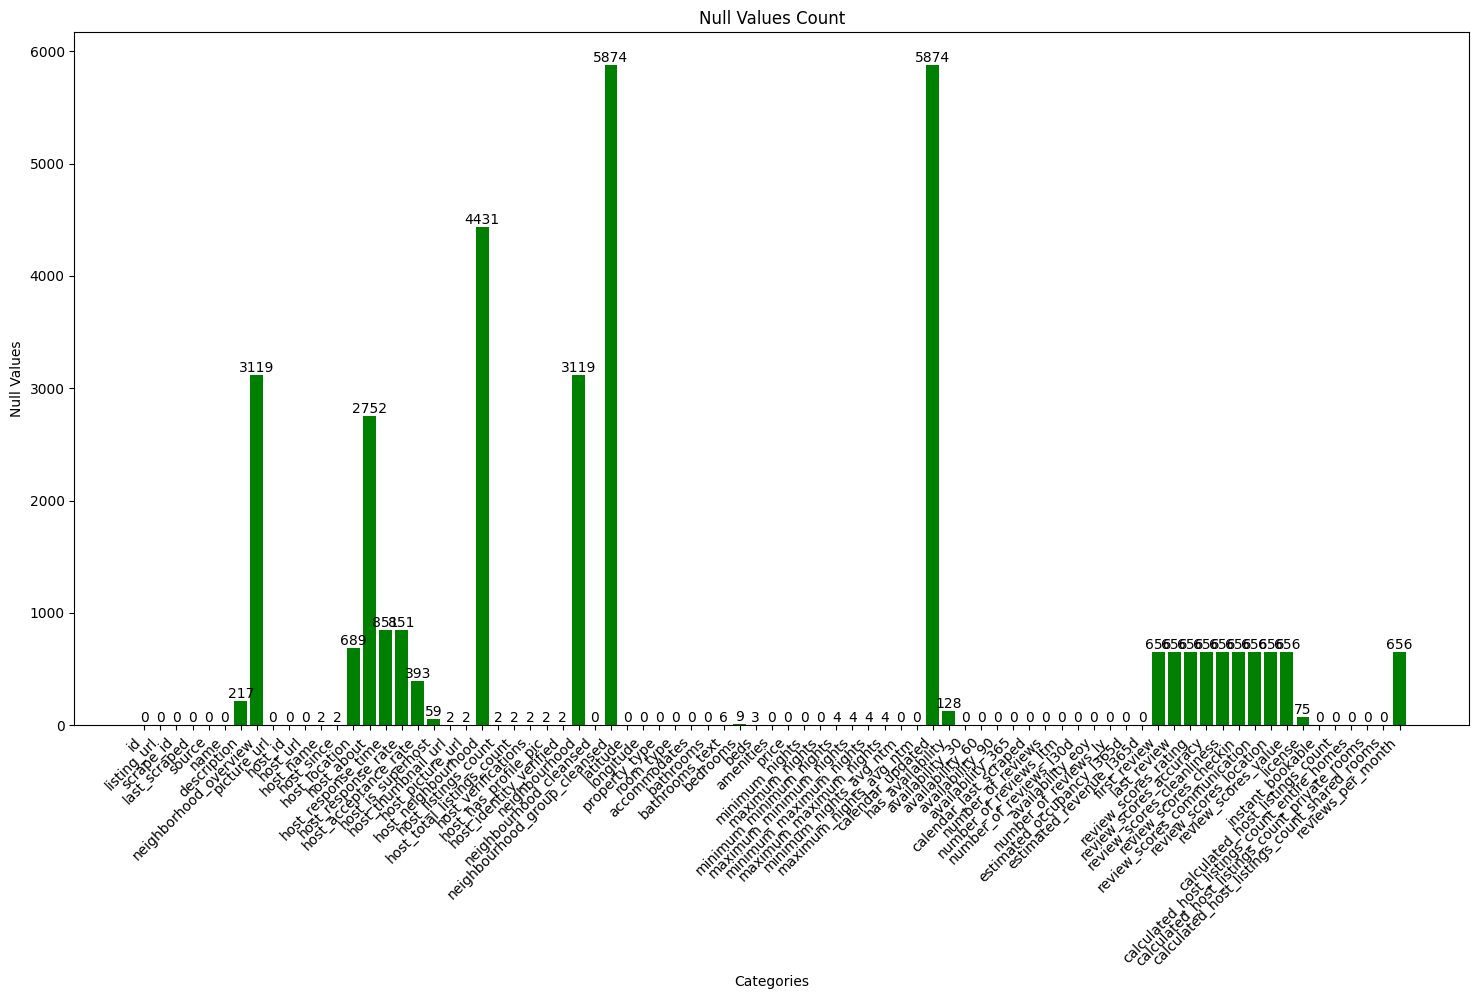

In [337]:
categories=categories_null_count.keys()
values=categories_null_count.values()

plt.figure(figsize=(18,9))
bars=plt.bar(categories, values, color='green')
plt.xlabel("Categories")
plt.ylabel("Null Values")
plt.xticks(rotation=45, ha='right')
plt.title("Null Values Count")

for i, bar in enumerate(bars):  # i=0→bar0, i=1→bar1, etc.
    height = bar.get_height()   # Gets values[i] for that bar
    plt.text(bar.get_x() + bar.get_width()/2, height,  # Centers on THIS bar
             f'{int(height)}', ha='center', va='bottom')

plt.show()

In [338]:
percentage_null_columns={}
col_40null=[]
for i in df.columns:
    null_pct=int(df[f"{i}"].isnull().sum())*100/5874
    percentage_null_columns.update({i: null_pct})
    if null_pct>40:
        col_40null.append(i)
col_40null 


['neighborhood_overview',
 'host_about',
 'host_neighbourhood',
 'neighbourhood',
 'neighbourhood_group_cleansed',
 'calendar_updated']

In [339]:
df.columns 

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [340]:
df.drop(["id","listing_url",'scrape_id','last_scraped','source','picture_url','host_id','host_url','host_thumbnail_url','host_picture_url','host_listings_count','neighbourhood_group_cleansed','calendar_updated','calendar_last_scraped','license','neighborhood_overview','host_about','host_neighbourhood','neighbourhood'], axis=1, inplace=True)

In [341]:
df.info() 

<class 'pandas.DataFrame'>
Index: 5874 entries, 0 to 10479
Data columns (total 60 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   name                                          5874 non-null   str    
 1   description                                   5657 non-null   str    
 2   host_name                                     5872 non-null   str    
 3   host_since                                    5872 non-null   str    
 4   host_location                                 5185 non-null   str    
 5   host_response_time                            5023 non-null   str    
 6   host_response_rate                            5023 non-null   str    
 7   host_acceptance_rate                          5481 non-null   str    
 8   host_is_superhost                             5815 non-null   str    
 9   host_total_listings_count                     5872 non-null   float64
 10  hos

In [342]:
dataset_info = {
    "columns": [], "nulls": [], "floats": [], "ints": [], 
    "strs": [], "dates": [], "bools": [], "objects": []
}

for col in df.columns:
    # Count null values
    null_count = df[col].isnull().sum()
    
    # Get type distribution (handles NaN properly)
    type_counts = {}
    for value in df[col]:
        if pd.isna(value):
            type_counts['<NA>']=type_counts.get('<NA>',0)+1
        else:
            type_counts[str(type(value).__name__)]=type_counts.get(str(type(value).__name__),0)+1
    
    dataset_info['columns'].append(col)
    dataset_info['nulls'].append(null_count)
    dataset_info['floats'].append(type_counts.get('float', 0))
    dataset_info['ints'].append(type_counts.get('int', 0))
    dataset_info['strs'].append(type_counts.get('str', 0))
    dataset_info['dates'].append(type_counts.get('datetime', 0) + type_counts.get('Timestamp', 0))
    dataset_info['bools'].append(type_counts.get('bool', 0))
    dataset_info['objects'].append(type_counts.get('object', 0) + type_counts.get('NoneType', 0))

# Convert to DataFrame for easy viewing
info_df = pd.DataFrame(dataset_info)
info_df

,columns,nulls,floats,ints,strs,dates,bools,objects
0,name,0,0,0,5874,0,0,0
1,description,217,0,0,5657,0,0,0
2,host_name,2,0,0,5872,0,0,0
3,host_since,2,0,0,5872,0,0,0
4,host_location,689,0,0,5185,0,0,0
5,host_response_time,851,0,0,5023,0,0,0
6,host_response_rate,851,0,0,5023,0,0,0
7,host_acceptance_rate,393,0,0,5481,0,0,0
8,host_is_superhost,59,0,0,5815,0,0,0
9,host_total_listings_count,2,5872,0,0,0,0,0


The above data shows that some columns have null values also. 
But no columns has more than 1 datatype.

In [343]:
df.description.iloc[:30] 

0     Stylish and romantic houseboat on fantastic hi...
1             Basic bedroom in the center of Amsterdam.
2     This room can also be rented as a single or a ...
5     Stylish & spacious 60m2 guest suite in Amsterd...
6     A beautiful 'De Lux' 125 sqm apartment for 4 a...
7     This is a beautiful family home in a lovely pa...
8     B&B “De 9 Straatjes” – Your home in the heart ...
15    Private room offered in elegant furnished, cle...
16    This lovely, three story monumental house is l...
21    Beautiful apartment in the peaceful "Amsterdam...
22    We would be delighted to host you in our guest...
23    Metropolitan B&B is a nice place in the centre...
25    This former artist's studio with bathroom take...
30    This unique property is a 16th century canal h...
31    Our lovely studio apartment is located near th...
33    You will have your own private floor with larg...
35    The apartment is part of our property on the g...
39    The apartment is a modern five bedroom apa

How to handle null values in the above case? (column name: description)\
So as the percentage of missing values is approx 4%, we must impute the null values with a string like "No description available". This will ensure that the machine understands cells with same type of descriptions and that they do convey something, as when we see that there is no description available for a listing, we basically don't prefer those listings and tend to book those very less often. So this underlying human behaviour can be understood by the machine as well. So when the machine will read this string "No description available" then it will understand that this cell does has some characteristic.

So I think that we can just impute the null values for above case with "No description avalable". 

In [344]:
df['description']=df['description'].fillna("No description available") 
df.description.isnull().sum() 

np.int64(0)

In [345]:
idx=df[df["host_name"].isnull()]
idx 

,name,description,host_name,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
4478,Lovely comfortable bed&breakfast with canal view,Bright and welcoming canal-side apartment in t...,NaN,NaN,NaN,NaN,NaN,NaN,f,NaN,...,4.54,4.77,4.91,4.66,f,1,0,1,0,0.75
9166,Spacious private garden floor,This spacious private garden floor is part of ...,NaN,NaN,NaN,NaN,NaN,NaN,t,NaN,...,4.95,4.95,4.95,4.90,f,1,0,1,0,6.72


In [346]:
df.loc[4475:4480]

,name,description,host_name,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
4478,Lovely comfortable bed&breakfast with canal view,Bright and welcoming canal-side apartment in t...,NaN,NaN,NaN,NaN,NaN,NaN,f,NaN,...,4.54,4.77,4.91,4.66,f,1,0,1,0,0.75
4480,Beautiful Amsterdam appartment by the water,This beautiful and cosy apartment is very spac...,Djinny,2015-07-22,"Amsterdam, Netherlands",within a few hours,80%,67%,f,4.0,...,5.00,4.77,4.77,4.77,f,1,1,0,0,0.28


For column "host_name" we can simply impute the missing column with the most frequent name or assign any random name in these cells, as there are only 2 null values in this column.  

In [347]:
# df['host_name'].fillna(df['host_name'].mode()[0], inplace=True)
df['host_name']=df['host_name'].fillna(df['host_name'].mode()[0]) 

In [348]:
idx=df[df['host_since'].isnull()]
idx 

,name,description,host_name,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
4478,Lovely comfortable bed&breakfast with canal view,Bright and welcoming canal-side apartment in t...,Stephan,NaN,NaN,NaN,NaN,NaN,f,NaN,...,4.54,4.77,4.91,4.66,f,1,0,1,0,0.75
9166,Spacious private garden floor,This spacious private garden floor is part of ...,Stephan,NaN,NaN,NaN,NaN,NaN,t,NaN,...,4.95,4.95,4.95,4.90,f,1,0,1,0,6.72


In [349]:
df['host_since']=df['host_since'].fillna(df['host_since'].mode()[0]) 

# here also we have imputed the null values with max occuring values in the column, since there are only 2 null values.

In [350]:
df['host_since']=df['host_since'].apply(lambda x: datetime.strptime(x, '%Y-%m-%d').year) 
df['host_since'].head() 
# Here we replace the string date with the year itself.

0    2010
1    2010
2    2010
5    2010
6    2010
Name: host_since, dtype: int64

In [351]:
df['host_location']=df['host_location'].fillna(df['host_location'].mode()[0])

# here for the column 'host_location' we impute the null values with the location which has occurred max number of times. This column contains 13% of null values.

In [352]:
df['host_response_time'].iloc[:30] 

0         within an hour
1         within an hour
2         within an hour
5     within a few hours
6         within an hour
7     a few days or more
8     within a few hours
15        within an hour
16        within an hour
21        within an hour
22        within an hour
23        within an hour
25        within an hour
30        within an hour
31          within a day
33          within a day
35        within an hour
39        within an hour
40        within an hour
41        within an hour
42    within a few hours
43    within a few hours
44                   NaN
45    within a few hours
46                   NaN
48    within a few hours
50        within an hour
51        within an hour
53    a few days or more
54        within an hour
Name: host_response_time, dtype: str

In [353]:
df['host_response_time'].value_counts() 

host_response_time
within an hour        2456
within a few hours    1196
within a day          1065
a few days or more     306
Name: count, dtype: int64

As observed from the distribution from the above 'host_response_time' column there are 4 unique key words that actually repeat throughout the column.\
Each unique key-word has on an average of approx 1250 counts. And from our calculation we know that here are 851 cell which are just blank, so rather than imputting these blank cells with the value occuring max times, we must simply replace these null values with "not specified". 

In [354]:
df['host_response_time']=df['host_response_time'].fillna('not specified')

In [355]:
df['host_response_rate'].value_counts() 

host_response_rate
100%    3690
0%       150
90%      125
50%      104
80%      101
        ... 
55%        1
36%        1
37%        1
64%        1
73%        1
Name: count, Length: 64, dtype: int64

In [356]:
df['host_response_rate']=df['host_response_rate'].fillna(df['host_response_rate'].mode()[0])

# As seen from the distribution, the 100% values is repeated max number of times so here we basically impute the null values with max occuring value.

In [357]:
df['host_acceptance_rate'].value_counts() 

host_acceptance_rate
100%    1624
0%       372
50%      260
99%      193
67%      158
        ... 
37%        3
49%        2
66%        2
2%         1
1%         1
Name: count, Length: 101, dtype: int64

In [358]:
df['host_acceptance_rate']=df['host_acceptance_rate'].fillna(df['host_acceptance_rate'].mode()[0])
df['host_is_superhost']=df['host_is_superhost'].fillna(df['host_is_superhost'].mode()[0])

# here also we do the same, simple impute the null values with max occuring values of these column.

In [359]:
valuecounts=df['host_total_listings_count'].value_counts()
valuecounts 

host_total_listings_count
1.0       3207
2.0       1120
3.0        468
4.0        265
5.0        144
6.0        105
7.0         72
15.0        54
8.0         44
11.0        38
9.0         37
13.0        36
10.0        32
85.0        30
23.0        28
24.0        21
18.0        20
17.0        18
12.0        18
14.0        13
69.0        12
21.0        10
22.0        10
1655.0       9
45.0         8
19.0         6
40.0         6
16.0         5
48.0         5
35.0         5
42.0         4
63.0         3
44.0         3
221.0        2
1052.0       2
94.0         2
27.0         1
230.0        1
133.0        1
541.0        1
32.0         1
98.0         1
34.0         1
31.0         1
79.0         1
219.0        1
Name: count, dtype: int64

In [360]:
sum(valuecounts.index[:15])/15

13.466666666666667

In [361]:
df['host_total_listings_count']=df['host_total_listings_count'].fillna(13)

# here we impute the missing value with the average of top 15 value occurences.

In [362]:
df['host_verifications'].value_counts() 

host_verifications
['email', 'phone']                  4716
['email', 'phone', 'work_email']     605
['phone']                            521
['phone', 'work_email']               24
[]                                     3
['email']                              2
['email', 'work_email']                1
Name: count, dtype: int64

In [363]:
df['host_verifications']=df['host_verifications'].fillna(df['host_verifications'].mode()[0])
df['host_has_profile_pic']=df['host_has_profile_pic'].fillna(df['host_has_profile_pic'].mode()[0])
df['host_identity_verified']=df['host_identity_verified'].fillna(df['host_identity_verified'].mode()[0])

# As there are only 2 null values we simple impute them with max occuring value.

In [364]:
df['bathrooms_text'].value_counts()

bathrooms_text
1 bath               3018
1.5 baths            1184
1 private bath        651
2 baths               334
1 shared bath         264
2.5 baths             112
1.5 shared baths      110
3 baths                62
0 baths                34
0 shared baths         22
3.5 baths              20
Half-bath              17
Shared half-bath        8
4 baths                 5
2 shared baths          5
5.5 baths               5
Private half-bath       4
5 baths                 4
4.5 baths               3
3 shared baths          3
12 baths                1
17 baths                1
6 baths                 1
Name: count, dtype: int64

In [365]:
df['bathrooms_text']=df['bathrooms_text'].fillna(df['bathrooms_text'].mode()[0]) 
# this column had only 6 null values, so imputted those with the max occuring values.

In [366]:
df['bedrooms'].value_counts()

bedrooms
1.0     3587
2.0     1419
3.0      500
0.0      167
4.0      154
5.0       27
8.0        5
10.0       3
6.0        1
7.0        1
17.0       1
Name: count, dtype: int64

In [367]:
df['bedrooms']=df['bedrooms'].fillna(df['bedrooms'].mode()[0])
# bedrooms had less percentage of null values, so replaced them with max occuring values.

In [368]:
df['beds'].value_counts()

beds
1.0     3075
2.0     1548
3.0      570
4.0      324
0.0      166
5.0       74
6.0       74
8.0        9
7.0        7
10.0       4
16.0       3
12.0       3
24.0       3
22.0       2
14.0       2
26.0       1
11.0       1
32.0       1
33.0       1
20.0       1
30.0       1
9.0        1
Name: count, dtype: int64

In [369]:
df['beds']=df['beds'].fillna(df['beds'].mode()[0]) 
# same imputation as above.

In [370]:
df['minimum_minimum_nights']=df['minimum_minimum_nights'].fillna(df['minimum_minimum_nights'].mode()[0])
df['maximum_minimum_nights']=df['maximum_minimum_nights'].fillna(df['maximum_minimum_nights'].mode()[0])
df['minimum_maximum_nights']=df['minimum_maximum_nights'].fillna(df['minimum_maximum_nights'].mode()[0])
df['maximum_maximum_nights']=df['maximum_maximum_nights'].fillna(df['maximum_maximum_nights'].mode()[0])

# these 4 columns are kind of related to each other, and the number of null values are also not much so we simply replace them with max occuring values.

In [371]:
df['has_availability'].nunique() 

1

In [372]:
df['has_availability']=df['has_availability'].fillna(df['has_availability'].mode()[0]) 
# imputted with max occuring 

In [373]:
df['first_review'].value_counts() 

first_review
2025-01-02    25
2025-04-21    24
2025-04-13    24
2024-09-16    19
2025-05-04    18
              ..
2025-07-02     1
2025-07-05     1
2025-08-13     1
2025-08-22     1
2025-09-10     1
Name: count, Length: 2257, dtype: int64

In [374]:
row_indices=df.index[df['first_review'].isnull()].tolist() 

In [375]:
df.drop(index=row_indices, inplace=True) 

In [376]:
df.isnull().sum() 

name                                            0
description                                     0
host_name                                       0
host_since                                      0
host_location                                   0
host_response_time                              0
host_response_rate                              0
host_acceptance_rate                            0
host_is_superhost                               0
host_total_listings_count                       0
host_verifications                              0
host_has_profile_pic                            0
host_identity_verified                          0
neighbourhood_cleansed                          0
latitude                                        0
longitude                                       0
property_type                                   0
room_type                                       0
accommodates                                    0
bathrooms                                       0


In [377]:
df.info()

<class 'pandas.DataFrame'>
Index: 5218 entries, 0 to 10443
Data columns (total 60 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   name                                          5218 non-null   str    
 1   description                                   5218 non-null   str    
 2   host_name                                     5218 non-null   str    
 3   host_since                                    5218 non-null   int64  
 4   host_location                                 5218 non-null   str    
 5   host_response_time                            5218 non-null   str    
 6   host_response_rate                            5218 non-null   str    
 7   host_acceptance_rate                          5218 non-null   str    
 8   host_is_superhost                             5218 non-null   str    
 9   host_total_listings_count                     5218 non-null   float64
 10  hos

In [378]:
# feature engineering 

In [379]:
df['host_response_rate'].loc[:10] 

# This column has the values in percentages and the datatype of these is string, 
# so here we can convert this column into numeric by removing the '%' symbol. 

0    100%
1    100%
2    100%
5    100%
6    100%
7      0%
8    100%
Name: host_response_rate, dtype: str

In [380]:
df['host_response_rate']=df['host_response_rate'].apply(lambda x: int(x[:-1])) 
df['host_response_rate'].head() 

0    100
1    100
2    100
5    100
6    100
Name: host_response_rate, dtype: int64

In [381]:
df['host_acceptance_rate']=df['host_acceptance_rate'].apply(lambda x: int(x[:-1]))
# 'host_acceptance_rate' is also a string column, we can convert this into numeric by removing the % sign.

In [382]:
df['host_acceptance_rate'].head()

0     97
1     99
2     99
5     93
6    100
Name: host_acceptance_rate, dtype: int64

In [383]:
df['host_is_superhost'].head(5) 
# this column consists of binary values, i.e it tells us whether the host is superhost or not. 't': superhost and 'f': not a superhost.
# Here we can convert this column into a numberic column by replacing the 't' by value 1 and 'f' by value 0.

0    t
1    t
2    t
5    t
6    f
Name: host_is_superhost, dtype: str

In [384]:
df['host_is_superhost']=df['host_is_superhost'].apply(lambda x: 1 if x=='t' else 0)
df['host_is_superhost'].head() 

0    1
1    1
2    1
5    1
6    0
Name: host_is_superhost, dtype: int64

In [385]:
df['host_verifications'].head(5)

0                  ['email', 'phone']
1                  ['email', 'phone']
2                  ['email', 'phone']
5    ['email', 'phone', 'work_email']
6                  ['email', 'phone']
Name: host_verifications, dtype: str

In [386]:
indices=df['host_verifications'].value_counts().index
indices 
# As we can see that this column has 6 unique values which are repeated in this column. So We can simply encode this values to a numeric value. 
# So '['email', 'phone']' will be 0, '['email', 'phone', 'work_email']' will be 1 and so on.


Index(['['email', 'phone']', '['email', 'phone', 'work_email']', '['phone']',
       '['phone', 'work_email']', '[]', '['email']',
       '['email', 'work_email']'],
      dtype='str', name='host_verifications')

In [387]:
hverification_encoder={}
j=0
for i in indices:
    hverification_encoder.update({i:j})
    j+=1
hverification_encoder 

{"['email', 'phone']": 0,
 "['email', 'phone', 'work_email']": 1,
 "['phone']": 2,
 "['phone', 'work_email']": 3,
 '[]': 4,
 "['email']": 5,
 "['email', 'work_email']": 6}

In [388]:
df['host_verifications']=df['host_verifications'].apply(lambda x: hverification_encoder.get(x))
df['host_verifications'].head()

0    0
1    0
2    0
5    1
6    0
Name: host_verifications, dtype: int64

In [389]:
df['host_has_profile_pic'].unique()

<StringArray>
['t', 'f']
Length: 2, dtype: str

In [390]:
df['host_has_profile_pic']=df['host_has_profile_pic'].apply(lambda x: 1 if x==1 else 0)
df['host_has_profile_pic'].head()
# here we replace "t" with 1 and "f" with 0.

0    0
1    0
2    0
5    0
6    0
Name: host_has_profile_pic, dtype: int64

In [391]:
df['host_identity_verified'].unique()
# here as well we can do the same thing, replace "t" with 1 and "f" with 0.

<StringArray>
['t', 'f']
Length: 2, dtype: str

In [392]:
df['host_identity_verified']=df['host_identity_verified'].apply(lambda x: 1 if x==1 else 0)
df['host_identity_verified'].head()

0    0
1    0
2    0
5    0
6    0
Name: host_identity_verified, dtype: int64

In [393]:
df['price']=df['price'].apply(lambda x: float(x[1:].replace(',','')))
df['price'].head()

0    132.0
1     89.0
2     61.0
5    322.0
6    457.0
Name: price, dtype: float64

In [394]:
df['neighbourhood_cleansed'].value_counts()                                                                                                                                             
# here we assume that the 'neighbourhood_cleansed' values are bounded/finite. 
# So here target encoding can be performed.
# Target encoding should be performed only on training dataset

neighbourhood_cleansed
De Baarsjes - Oud-West                    884
Centrum-West                              706
De Pijp - Rivierenbuurt                   561
Centrum-Oost                              532
Zuid                                      379
Westerpark                                353
Oud-Oost                                  283
Bos en Lommer                             229
Oud-Noord                                 225
Oostelijk Havengebied - Indische Buurt    204
Noord-West                                154
Watergraafsmeer                           116
Noord-Oost                                108
IJburg - Zeeburgereiland                   96
Slotervaart                                91
Geuzenveld - Slotermeer                    83
Buitenveldert - Zuidas                     59
De Aker - Nieuw Sloten                     37
Osdorp                                     35
Bijlmer-Centrum                            35
Gaasperdam - Driemond                      28
Bijlmer-Oos

In [395]:
neighbour_cleansed=df.groupby('neighbourhood_cleansed')['price'].mean()
neighbour_cleansed.head()

neighbourhood_cleansed
Bijlmer-Centrum            144.514286
Bijlmer-Oost               157.500000
Bos en Lommer              204.759825
Buitenveldert - Zuidas    1909.762712
Centrum-Oost               296.941729
Name: price, dtype: float64

In [396]:
df['neighbourhood_cleansed_encoded']=df['neighbourhood_cleansed'].map(neighbour_cleansed)
df.drop(columns=['neighbourhood_cleansed'], inplace=True)
df['neighbourhood_cleansed_encoded'].head()

0    318.076487
1    318.076487
2    296.941729
5    318.076487
6    296.941729
Name: neighbourhood_cleansed_encoded, dtype: float64

In [397]:
df['property_type'].value_counts()
# Target encoding 

property_type
Entire rental unit                    2002
Entire condo                           828
Entire home                            494
Private room in rental unit            273
Private room in bed and breakfast      241
Private room in condo                  139
Entire loft                            134
Private room in home                   108
Houseboat                              106
Entire serviced apartment              102
Entire townhouse                        92
Boat                                    84
Room in hotel                           78
Private room in houseboat               71
Room in boutique hotel                  68
Private room in townhouse               52
Private room in guest suite             51
Entire guesthouse                       32
Private room in boat                    31
Private room in loft                    30
Entire guest suite                      27
Private room in guesthouse              26
Private room in serviced apartment      

In [398]:
property_type_mapping=df.groupby('property_type')['price'].mean()
property_type_mapping.head()

property_type
Barn                195.500000
Boat               1285.964286
Casa particular     318.500000
Entire cabin        183.857143
Entire condo        297.682367
Name: price, dtype: float64

In [399]:
df['property_type_encoded']=df['property_type'].map(property_type_mapping)
df.drop(columns=['property_type'], inplace=True)
df['property_type_encoded'].head()

0    185.197183
1    131.747253
2    134.115108
5    201.481481
6    297.682367
Name: property_type_encoded, dtype: float64

In [400]:
df['room_type'].value_counts() 
# one hot encoding
# Here we see that Hotel room and Shared room fall into rare category class, so these 2 can be clubbed into a single class, 'other'

room_type
Entire home/apt    3957
Private room       1210
Hotel room           35
Shared room          16
Name: count, dtype: int64

In [401]:
df['room_type']=df['room_type'].replace({'Hotel room': 'Other', 'Shared room': 'Other'})
df['room_type'].head()

0       Private room
1       Private room
2       Private room
5    Entire home/apt
6    Entire home/apt
Name: room_type, dtype: str

In [402]:
df=pd.get_dummies(df, columns=['room_type'], drop_first=True, dtype=int)
df.head()

,name,description,host_name,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,neighbourhood_cleansed_encoded,property_type_encoded,room_type_Other,room_type_Private room
0,"Romantic, stylish B&B houseboat in canal district",Stylish and romantic houseboat on fantastic hi...,Flip,2010,"Amsterdam, Netherlands",within an hour,100,97,1,1.0,...,f,1,0,1,0,1.87,318.076487,185.197183,0,1
1,Comfortable double room,Basic bedroom in the center of Amsterdam.,Edwin,2010,"Amsterdam, Netherlands",within an hour,100,99,1,2.0,...,f,2,0,2,0,3.99,318.076487,131.747253,0,1
2,Comfortable single / double room,This room can also be rented as a single or a ...,Edwin,2010,"Amsterdam, Netherlands",within an hour,100,99,1,2.0,...,f,2,0,2,0,4.81,296.941729,134.115108,0,1
5,Multatuli Luxury Guest Suite in top location,Stylish & spacious 60m2 guest suite in Amsterd...,Joanna & MP,2010,"Amsterdam, Netherlands",within a few hours,100,93,1,2.0,...,f,1,1,0,0,3.36,318.076487,201.481481,0,0
6,Central de Lux 2 bedrooms (4p) apt 125 sqm,A beautiful 'De Lux' 125 sqm apartment for 4 a...,Donald,2010,"Amsterdam, Netherlands",within an hour,100,100,0,1.0,...,f,1,1,0,0,0.97,296.941729,297.682367,0,0


In [403]:
df['bathrooms_text'].value_counts()
# regex based encoding
# extract numerical value from the text value and store these values in new column. 

bathrooms_text
1 bath               2591
1.5 baths            1103
1 private bath        624
2 baths               285
1 shared bath         232
1.5 shared baths      107
2.5 baths              98
3 baths                58
0 baths                34
0 shared baths         22
3.5 baths              19
Half-bath              13
Shared half-bath        7
2 shared baths          5
4 baths                 4
Private half-bath       3
5 baths                 3
5.5 baths               3
4.5 baths               3
3 shared baths          3
12 baths                1
Name: count, dtype: int64

In [404]:
def extract_bathroom_number(text):
    if pd.isna(text):
        return None
    
    # Extract numbers (including decimals)
    numbers = re.findall(r'\d+\.?\d*', str(text))
    
    if numbers:
        return float(numbers[0])
    elif 'half' in str(text).lower():
        return 0.5
    else:
        return 0

df['bathroom_count'] = df['bathrooms_text'].apply(extract_bathroom_number)
df.drop(columns=['bathrooms_text'], inplace=True)
df['bathroom_count'].head()

0    1.5
1    1.0
2    1.0
5    1.0
6    1.5
Name: bathroom_count, dtype: float64

In [405]:
df['amenities'].loc[1] 
# Each cell of the column 'amenities' contains list of amenities there are various way to perform feature engineering on this.
# 1. Out of all the individual emenities we can list the top 25 amenities, and make features out of those. So 25 extra feature will be added to the df 
# and if a particular feature/amenity is present then it's corresponding cell will be given 1 as value.
# 2. We can simple mention the number of amenities for a listing.(This approach sounds good as it is simple to implement and interpretable)

'["Heating", "Lock on bedroom door", "Hair dryer", "Private entrance", "Carbon monoxide alarm", "Cleaning products", "Smoke alarm", "Refrigerator", "Wifi", "Hot water", "Bed linens", "Hangers", "Essentials", "Host greets you", "Iron", "Shampoo", "Coffee maker", "Fire extinguisher"]'

In [406]:
def count_amenities(amenity_string):
    if pd.isna(amenity_string):
        return 0
    try:
        amenity_list = ast.literal_eval(amenity_string)
        return len(amenity_list)
    except:
        return 0

df['amenity_count'] = df['amenities'].apply(lambda x: count_amenities(x))
df.drop(columns=['amenities'], inplace=True)
df['amenity_count'].unique()
# This newly created 'amenity_count' represents the number of amenities a listing has. 

array([50, 18, 52, 48, 38, 20, 15, 56, 49, 59, 35, 57, 44, 69, 36, 34, 27,
       45, 19, 11, 40, 21, 46, 53, 23, 26, 33, 42, 30, 24, 13, 22, 41, 29,
       47, 73, 51, 63, 28,  9, 25, 55, 68, 54, 37, 10, 12, 67, 32, 64,  8,
       58, 62, 72, 39, 16, 31, 71, 43, 60, 84, 76,  2, 14, 17,  5,  6, 77,
       65, 61, 66,  0, 75,  7, 99, 79, 81,  3, 70, 74,  4, 78, 80,  1])

In [407]:
df['price'].head()

0    132.0
1     89.0
2     61.0
5    322.0
6    457.0
Name: price, dtype: float64

In [408]:
df['has_availability']=df['has_availability'].apply(lambda x: 1 if x=='t' else 0)
df['has_availability'].head()
# 'has_availability' has values 't' or 'f' so here label encoding can be performed, so 't' is 1 and 'f' is 0.

0    1
1    1
2    1
5    1
6    1
Name: has_availability, dtype: int64

In [409]:
df['first_review'].head() 
# Here as we can see that the year for the first review matters more, we can store only the year for this column.

0    2012-01-09
1    2010-08-22
2    2011-03-16
5    2010-10-29
6    2010-10-13
Name: first_review, dtype: str

In [410]:
df['first_review']=df['first_review'].apply(lambda x: datetime.strptime(x, '%Y-%m-%d').year)
df['first_review'].head() 

0    2012
1    2010
2    2011
5    2010
6    2010
Name: first_review, dtype: int64

In [411]:
df['last_review'].head() 
# Here also we can simply keep the last review year as it tell us, the last year when the review was given.

0    2025-09-07
1    2025-09-07
2    2025-09-08
5    2025-08-26
6    2025-09-01
Name: last_review, dtype: str

In [412]:
df['last_review']=df['last_review'].apply(lambda x: datetime.strptime(x,'%Y-%m-%d').year)
df['last_review'].head() 

0    2025
1    2025
2    2025
5    2025
6    2025
Name: last_review, dtype: int64

In [413]:
df['instant_bookable'].unique() 
# Here we replace 't' with 1 and 'f' with  

<StringArray>
['f', 't']
Length: 2, dtype: str

In [414]:
df['instant_bookable']=df['instant_bookable'].apply(lambda x: 1 if x=='t' else 0)
df['instant_bookable'].head()

0    0
1    0
2    0
5    0
6    0
Name: instant_bookable, dtype: int64

In [415]:
df['instant_bookable'].unique()

array([0, 1])

In [416]:
df['host_since'].head()

0    2010
1    2010
2    2010
5    2010
6    2010
Name: host_since, dtype: int64

In [417]:
df.info()

<class 'pandas.DataFrame'>
Index: 5218 entries, 0 to 10443
Data columns (total 61 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   name                                          5218 non-null   str    
 1   description                                   5218 non-null   str    
 2   host_name                                     5218 non-null   str    
 3   host_since                                    5218 non-null   int64  
 4   host_location                                 5218 non-null   str    
 5   host_response_time                            5218 non-null   str    
 6   host_response_rate                            5218 non-null   int64  
 7   host_acceptance_rate                          5218 non-null   int64  
 8   host_is_superhost                             5218 non-null   int64  
 9   host_total_listings_count                     5218 non-null   float64
 10  hos

In [418]:
df['name']

0        Romantic, stylish B&B houseboat in canal district
1                                  Comfortable double room
2                         Comfortable single / double room
5             Multatuli Luxury Guest Suite in top location
6               Central de Lux 2 bedrooms (4p) apt 125 sqm
                               ...                        
10414                     Pearl & Tulip 2BR + Free Parking
10417                     Studio in the heart of Amsterdam
10427                       Stylish Apt - Close to Jordaan
10442             Sergio's Houseboat in 'de Jordaan', Luna
10443             Sergio's Houseboat in 'de Jordaan', Tide
Name: name, Length: 5218, dtype: str

In [419]:
tfidf=TfidfVectorizer(stop_words='english', max_features=20)
x=tfidf.fit_transform(df['name'])

In [420]:
X_df = pd.DataFrame(x.toarray(), columns=tfidf.get_feature_names_out())

df = df.reset_index(drop=True)
X_df = X_df.reset_index(drop=True)

df_final = pd.concat([df, X_df], axis=1)

df = df_final.drop(columns=['name'])

In [421]:
df.head()

,description,host_name,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_verifications,...,garden,home,house,modern,near,private,room,spacious,studio,view
0,Stylish and romantic houseboat on fantastic hi...,Flip,2010,"Amsterdam, Netherlands",within an hour,100,97,1,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Basic bedroom in the center of Amsterdam.,Edwin,2010,"Amsterdam, Netherlands",within an hour,100,99,1,2.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,This room can also be rented as a single or a ...,Edwin,2010,"Amsterdam, Netherlands",within an hour,100,99,1,2.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,Stylish & spacious 60m2 guest suite in Amsterd...,Joanna & MP,2010,"Amsterdam, Netherlands",within a few hours,100,93,1,2.0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,A beautiful 'De Lux' 125 sqm apartment for 4 a...,Donald,2010,"Amsterdam, Netherlands",within an hour,100,100,0,1.0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [422]:
df['host_name'].head()
# we assume for simplicity that, name of host will not have much impact on the price of a listing. So we simple drop this column.

0           Flip
1          Edwin
2          Edwin
3    Joanna & MP
4         Donald
Name: host_name, dtype: str

In [423]:
df.drop(columns=['host_name'], inplace=True)
df.columns

Index(['description', 'host_since', 'host_location', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'latitude',
       'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'has_availability', 'availability_30',
       'availability_60', 'availability_90', 'availability_365',
       'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d',
       'availability_eoy', 'number_of_reviews_ly', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d', 'first_review', 'last_review',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'revi

In [424]:
df['host_location'].head()

0    Amsterdam, Netherlands
1    Amsterdam, Netherlands
2    Amsterdam, Netherlands
3    Amsterdam, Netherlands
4    Amsterdam, Netherlands
Name: host_location, dtype: str

In [425]:
tfidf=TfidfVectorizer(stop_words='english', max_features=20)

x=tfidf.fit_transform(df['host_location'])

x_df=pd.DataFrame(x.toarray(), columns=tfidf.get_feature_names_out())

x_df.reset_index(drop=True)
df.reset_index(drop=True)

df=pd.concat([df, x_df], axis=1)
df.drop(columns=['host_location'], inplace=True)

In [426]:
df.head()

,description,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,...,huizen,kingdom,london,netherlands,new,paris,rotterdam,spain,united,utrecht
0,Stylish and romantic houseboat on fantastic hi...,2010,within an hour,100,97,1,1.0,0,0,0,...,0.0,0.0,0.0,0.689337,0.0,0.0,0.0,0.0,0.0,0.0
1,Basic bedroom in the center of Amsterdam.,2010,within an hour,100,99,1,2.0,0,0,0,...,0.0,0.0,0.0,0.689337,0.0,0.0,0.0,0.0,0.0,0.0
2,This room can also be rented as a single or a ...,2010,within an hour,100,99,1,2.0,0,0,0,...,0.0,0.0,0.0,0.689337,0.0,0.0,0.0,0.0,0.0,0.0
3,Stylish & spacious 60m2 guest suite in Amsterd...,2010,within a few hours,100,93,1,2.0,1,0,0,...,0.0,0.0,0.0,0.689337,0.0,0.0,0.0,0.0,0.0,0.0
4,A beautiful 'De Lux' 125 sqm apartment for 4 a...,2010,within an hour,100,100,0,1.0,0,0,0,...,0.0,0.0,0.0,0.689337,0.0,0.0,0.0,0.0,0.0,0.0


In [427]:
df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 5218 entries, 0 to 5217
Data columns (total 98 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   description                                   5218 non-null   str    
 1   host_since                                    5218 non-null   int64  
 2   host_response_time                            5218 non-null   str    
 3   host_response_rate                            5218 non-null   int64  
 4   host_acceptance_rate                          5218 non-null   int64  
 5   host_is_superhost                             5218 non-null   int64  
 6   host_total_listings_count                     5218 non-null   float64
 7   host_verifications                            5218 non-null   int64  
 8   host_has_profile_pic                          5218 non-null   int64  
 9   host_identity_verified                        5218 non-null   int64  
 10 

In [428]:
df['description'].head()
# since description and name columns are mostly similar, we decide to drop this column as we already have 101 columns till now.

0    Stylish and romantic houseboat on fantastic hi...
1            Basic bedroom in the center of Amsterdam.
2    This room can also be rented as a single or a ...
3    Stylish & spacious 60m2 guest suite in Amsterd...
4    A beautiful 'De Lux' 125 sqm apartment for 4 a...
Name: description, dtype: str

In [429]:
df.drop(columns=['description'], inplace=True)

In [430]:
df['host_response_time'].value_counts()

host_response_time
within an hour        2296
within a few hours    1076
within a day           916
not specified          683
a few days or more     247
Name: count, dtype: int64

In [431]:
df['host_response_time']=df['host_response_time'].replace({'within an hour': 5, 'within a few hours': 4, 'within a day': 3, 'a few days or more': 2, 'not specified': 1})
df['host_response_time'].head()

0    5
1    5
2    5
3    4
4    5
Name: host_response_time, dtype: object

In [432]:
df.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 5218 entries, 0 to 5217
Data columns (total 97 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   host_since                                    5218 non-null   int64  
 1   host_response_time                            5218 non-null   object 
 2   host_response_rate                            5218 non-null   int64  
 3   host_acceptance_rate                          5218 non-null   int64  
 4   host_is_superhost                             5218 non-null   int64  
 5   host_total_listings_count                     5218 non-null   float64
 6   host_verifications                            5218 non-null   int64  
 7   host_has_profile_pic                          5218 non-null   int64  
 8   host_identity_verified                        5218 non-null   int64  
 9   latitude                                      5218 non-null   float64
 10 